#### Dataset

##### Cài thư viện

In [2]:
import idx2numpy
import pickle

image_file = "data/EMNIST/raw/emnist-balanced-train-images-idx3-ubyte"
label_file = "data/EMNIST/raw/emnist-balanced-train-labels-idx1-ubyte"

X = idx2numpy.convert_from_file(image_file)
y = idx2numpy.convert_from_file(label_file)

print(X.shape)
print(y.shape)

(112800, 28, 28)
(112800,)


In [ ]:
data = {
    "x": X,
    "y": y
}

with open("data/emnist_full.pkl", "wb") as f:
    pickle.dump(data, f)

##### Chia iid

In [5]:
import numpy as np
import os
import pickle

NUM_CLIENTS = 6

os.makedirs("data_new/iid", exist_ok=True)

num_samples = len(X)

indices = np.arange(num_samples)
np.random.shuffle(indices)

splits = np.array_split(indices, NUM_CLIENTS)

for i, idx in enumerate(splits):

    client_images = X[idx]
    client_labels = y[idx]

    with open(f"data_new/iid/client_{i}.pkl","wb") as f:
        pickle.dump({
            "images": client_images,
            "labels": client_labels
        }, f)

    print(f"client_{i}: {len(set(client_labels))} labels")

client_0: 47 labels
client_1: 47 labels
client_2: 47 labels
client_3: 47 labels
client_4: 47 labels
client_5: 47 labels


##### Chia Non_iid

In [ ]:
import random
import os
import pickle
from collections import defaultdict

os.makedirs("data_new/non_iid_fixed", exist_ok=True)

NUM_CLIENTS = 6
MIN_SAMPLES = 16000
MAX_SAMPLES = 17000

label_dict = defaultdict(list)

for img, label in zip(X, y):
    label_dict[label].append(img)

labels = list(range(47))

# ===============================
# 1. Gán mỗi label cho 2–3 client
# ===============================
label_to_clients = {}

for l in labels:
    k = random.randint(2, 3)
    clients = random.sample(range(NUM_CLIENTS), k)
    label_to_clients[l] = clients

# ===============================
# 2. Mapping ngược
# ===============================
client_to_labels = defaultdict(list)

for l, clients in label_to_clients.items():
    for c in clients:
        client_to_labels[c].append(l)

# ===============================
# 3. Generate data với tổng fix
# ===============================
for client in range(NUM_CLIENTS):

    client_images = []
    client_labels = []

    keep_labels = client_to_labels[client]

    target_samples = random.randint(MIN_SAMPLES, MAX_SAMPLES)

    # 🔥 tạo weight để imbalance
    weights = [random.random() for _ in keep_labels]
    total_weight = sum(weights)

    samples_per_label = [
        int(w / total_weight * target_samples)
        for w in weights
    ]

    # fix sai số (đảm bảo tổng đúng)
    diff = target_samples - sum(samples_per_label)
    for i in range(abs(diff)):
        idx = i % len(samples_per_label)
        samples_per_label[idx] += 1 if diff > 0 else -1

    # ===============================
    # lấy data
    # ===============================
    for l, num_samples in zip(keep_labels, samples_per_label):

        imgs = label_dict[l]

        sample = random.sample(imgs, min(num_samples, len(imgs)))

        client_images.extend(sample)
        client_labels.extend([l] * len(sample))

    with open(f"data_new/non_iid_fixed/client_{client}.pkl", "wb") as f:
        pickle.dump({
            "images": client_images,
            "labels": client_labels
        }, f)

    print(f"client_{client}: {len(client_labels)} samples | {len(keep_labels)} labels")

client_0: 16629 samples | 16 labels
client_1: 16487 samples | 14 labels
client_2: 16719 samples | 21 labels
client_3: 16251 samples | 23 labels
client_4: 16936 samples | 19 labels
client_5: 16706 samples | 20 labels

===== LABEL -> CLIENTS =====
label 0: clients [5, 1, 3]
label 1: clients [0, 4, 2]
label 2: clients [4, 2]
label 3: clients [5, 3, 1]
label 4: clients [4, 0]
label 5: clients [4, 2]
label 6: clients [5, 3]
label 7: clients [3, 2, 4]
label 8: clients [3, 2, 1]
label 9: clients [2, 3, 0]
label 10: clients [0, 5]
label 11: clients [2, 0]
label 12: clients [2, 5]
label 13: clients [1, 5]
label 14: clients [1, 2]
label 15: clients [5, 3]
label 16: clients [1, 0, 2]
label 17: clients [4, 3, 1]
label 18: clients [3, 2]
label 19: clients [0, 3]
label 20: clients [1, 2, 3]
label 21: clients [3, 0, 4]
label 22: clients [3, 1]
label 23: clients [5, 3, 4]
label 24: clients [3, 4]
label 25: clients [5, 4, 0]
label 26: clients [0, 5]
label 27: clients [4, 5]
label 28: clients [0, 3]
lab

#### Test Dataset

##### Kiểm tra số lượng nhãn

In [21]:
import os
import pickle

def count_labels_per_client(folder_path):
    print(f"\n===== {folder_path} =====")

    for file in sorted(os.listdir(folder_path)):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                data = pickle.load(f)

            y = data["labels"]
            num_labels = len(set(y)) 

            print(f"{file}: {num_labels} labels")

count_labels_per_client("./data_new/iid")
count_labels_per_client("./data_new/non_iid")


===== ./data_new/iid =====
client_0.pkl: 47 labels
client_1.pkl: 47 labels


client_2.pkl: 47 labels
client_3.pkl: 47 labels
client_4.pkl: 47 labels
client_5.pkl: 47 labels

===== ./data_new/non_iid =====
client_0.pkl: 16 labels
client_1.pkl: 14 labels
client_2.pkl: 21 labels
client_3.pkl: 23 labels
client_4.pkl: 19 labels
client_5.pkl: 20 labels


##### Kiểm tra số lượng mẫu

In [22]:
import os
import pickle

def count_samples_per_client(folder_path):
    print(f"\n===== {folder_path} =====")

    for file in sorted(os.listdir(folder_path)):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                data = pickle.load(f)

            y = data["labels"]
            num_samples = len(y)

            print(f"{file}: {num_samples} samples")


# chạy
count_samples_per_client("./data_new/iid")
count_samples_per_client("./data_new/non_iid")


===== ./data_new/iid =====
client_0.pkl: 18800 samples
client_1.pkl: 18800 samples
client_2.pkl: 18800 samples
client_3.pkl: 18800 samples
client_4.pkl: 18800 samples
client_5.pkl: 18800 samples

===== ./data_new/non_iid =====
client_0.pkl: 16629 samples
client_1.pkl: 16487 samples
client_2.pkl: 16719 samples
client_3.pkl: 16251 samples
client_4.pkl: 16936 samples
client_5.pkl: 16706 samples


##### Hình chi tiết từng client

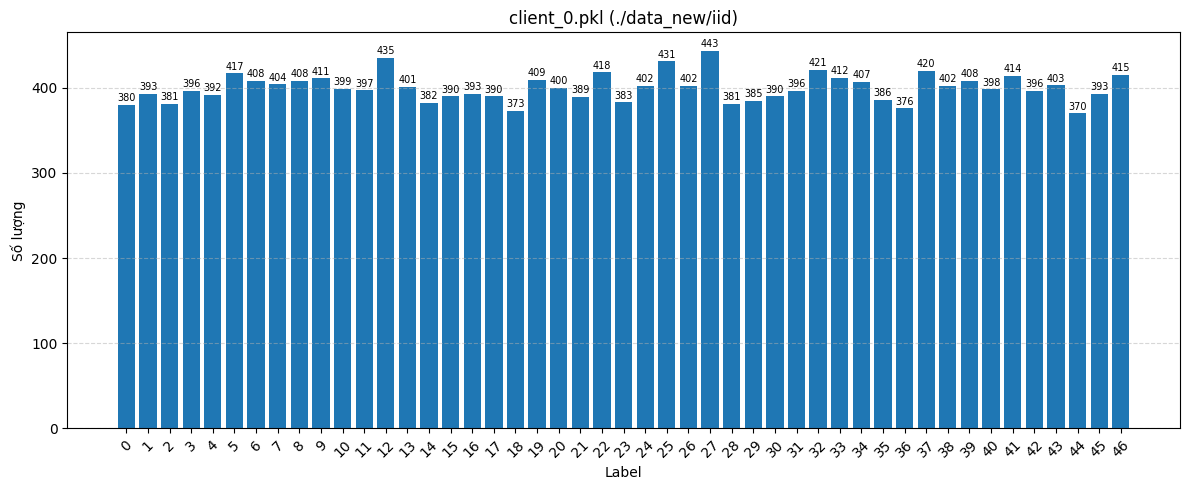

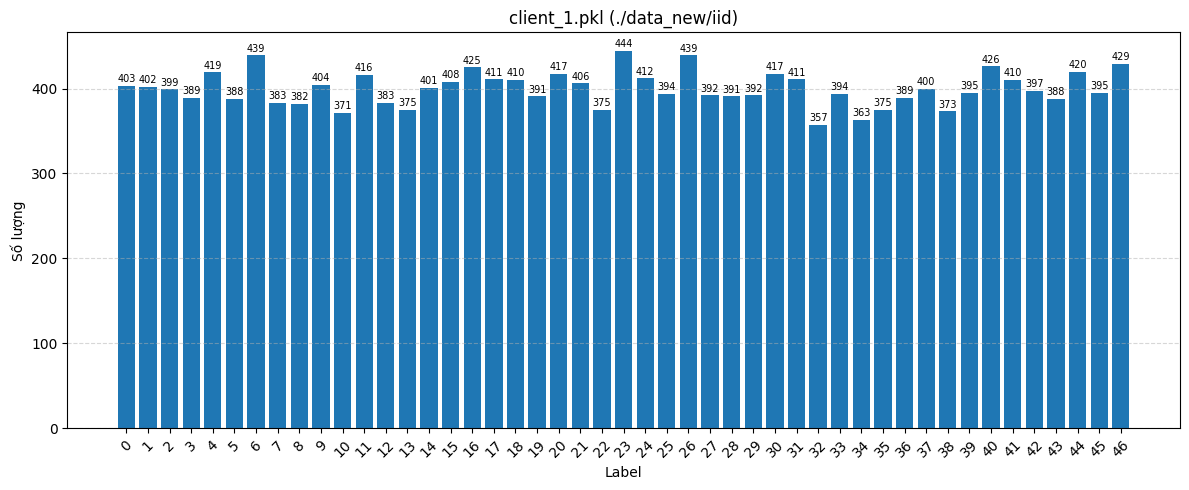

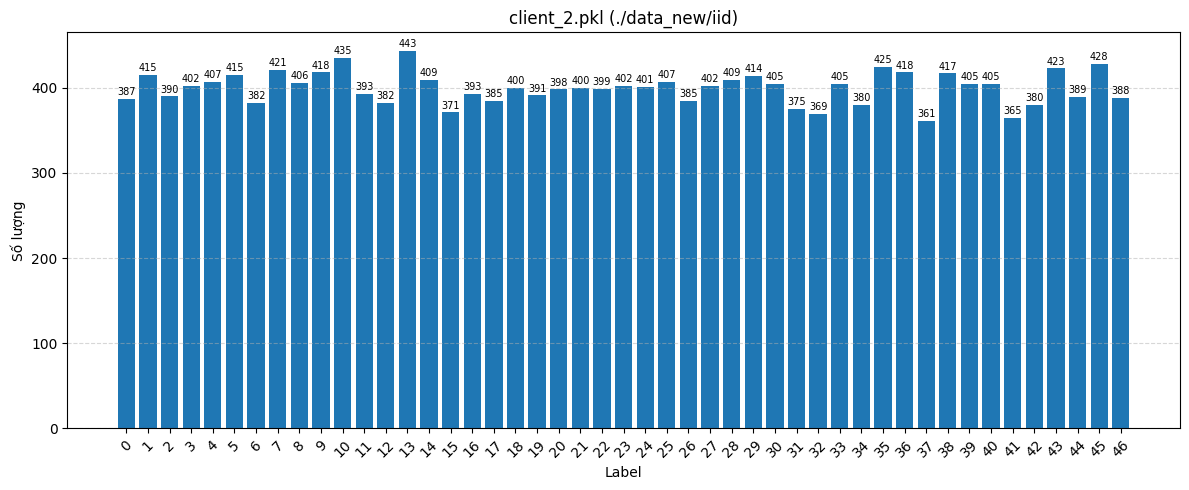

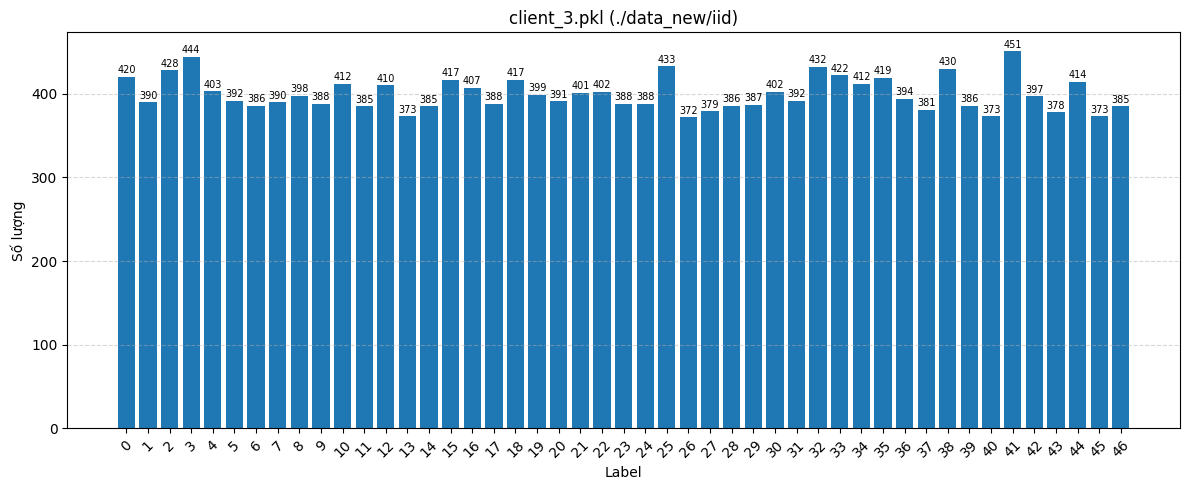

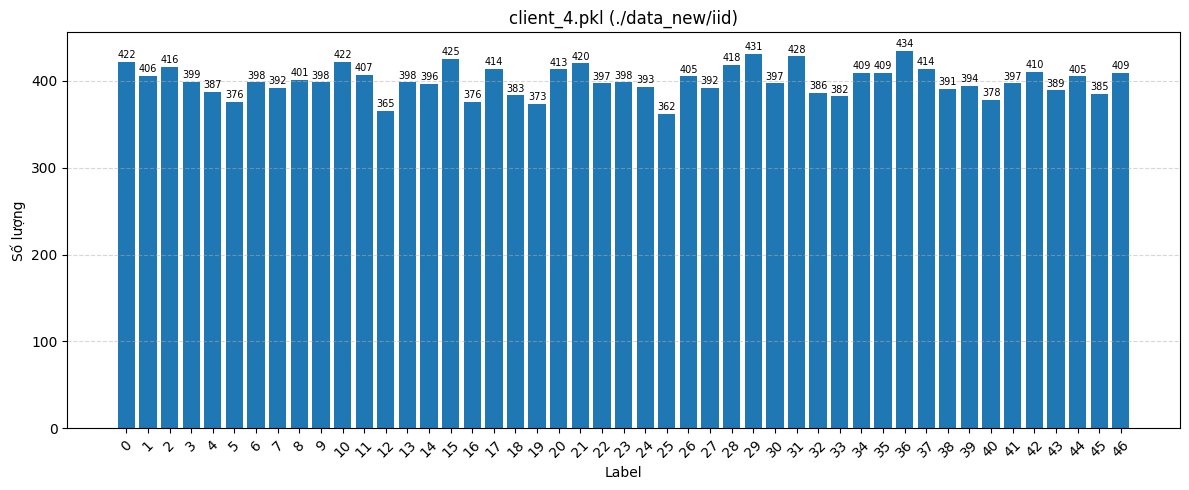

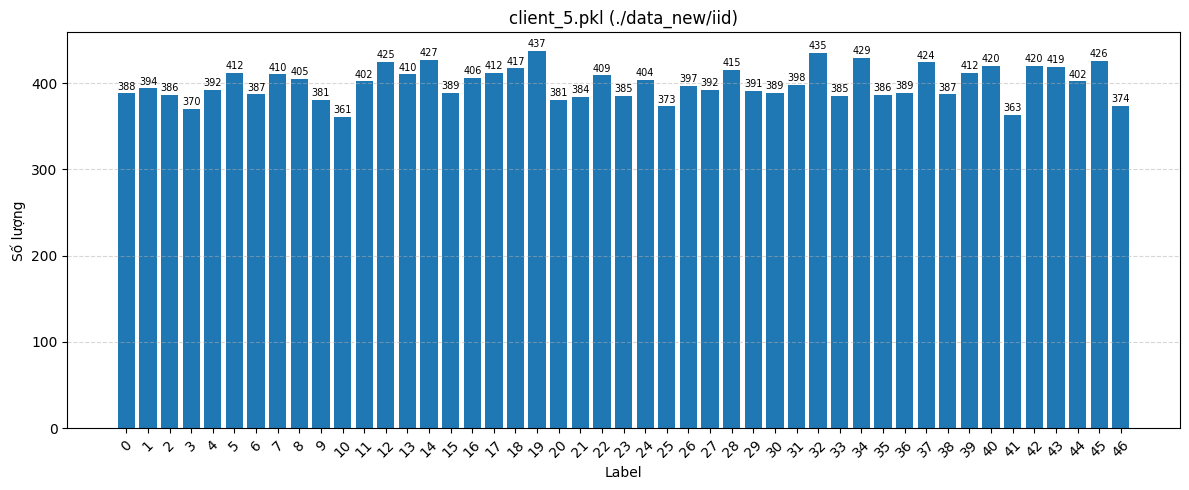

In [23]:
import os
import pickle
from collections import Counter
import matplotlib.pyplot as plt

def plot_each_client_beautiful(folder_path):
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".pkl")])

    for file in files:
        with open(os.path.join(folder_path, file), "rb") as f:
            data = pickle.load(f)

        y = data["labels"]
        counter = Counter(y)

        all_labels = list(range(max(counter.keys()) + 1))
        values = [counter.get(l, 0) for l in all_labels]

        plt.figure(figsize=(12,5))
        bars = plt.bar(all_labels, values)

        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.text(bar.get_x() + bar.get_width()/2,
                         height + 2,
                         str(int(height)),
                         ha='center', va='bottom', fontsize=7)

        plt.xticks(all_labels, rotation=45) 

        plt.xlabel("Label")
        plt.ylabel("Số lượng")
        plt.title(f"{file} ({folder_path})")

        plt.grid(axis='y', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

plot_each_client_beautiful("./data_new/iid")

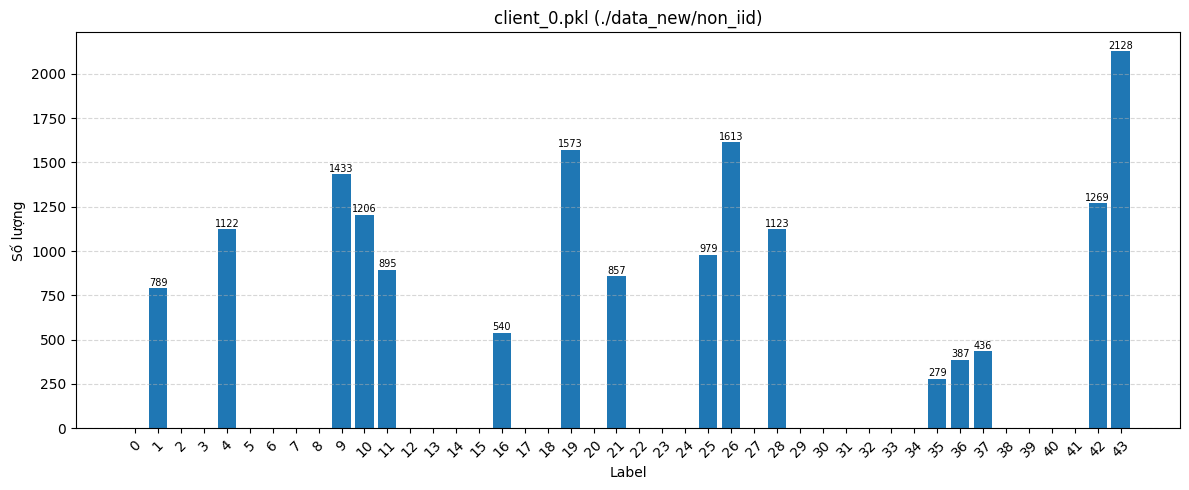

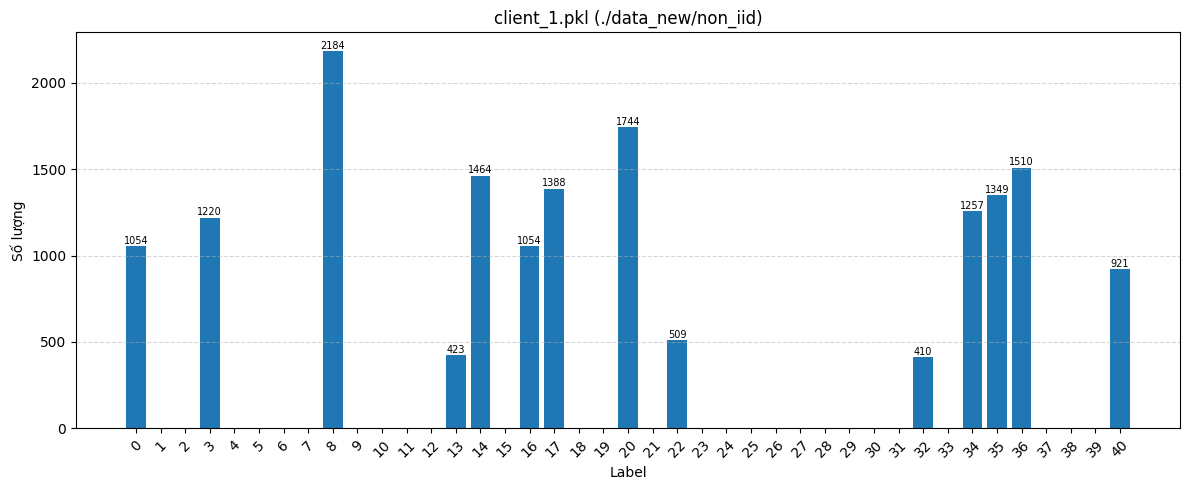

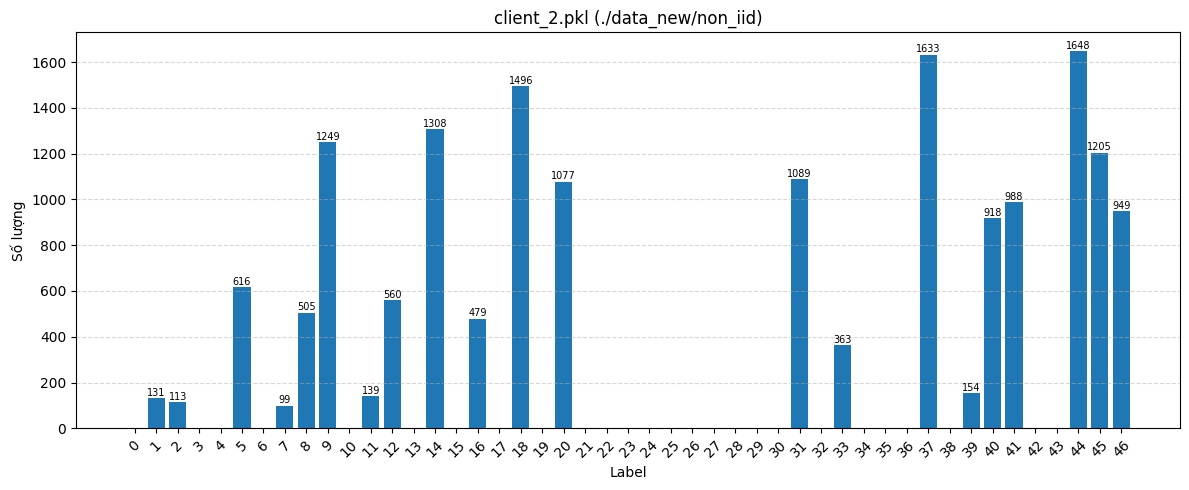

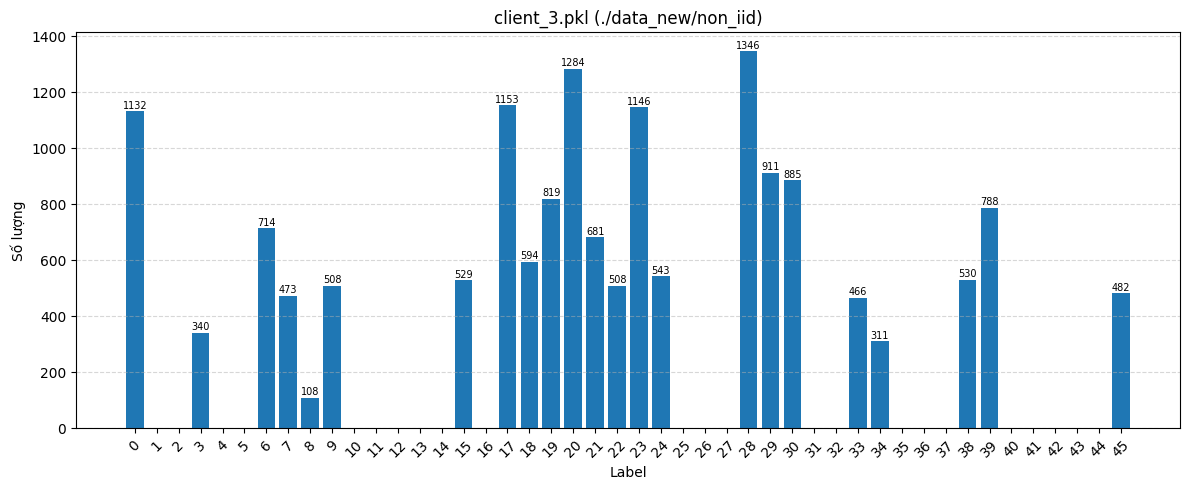

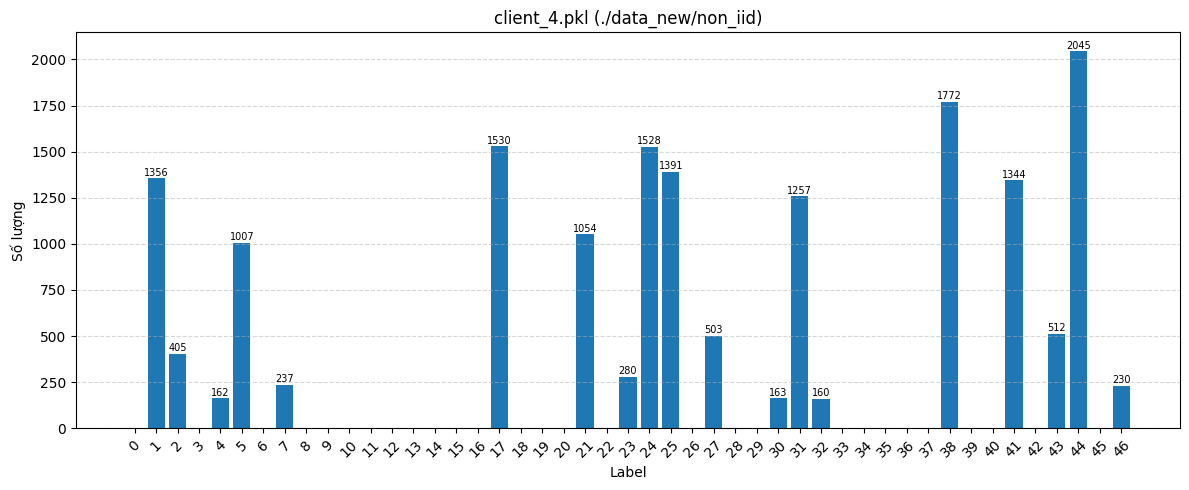

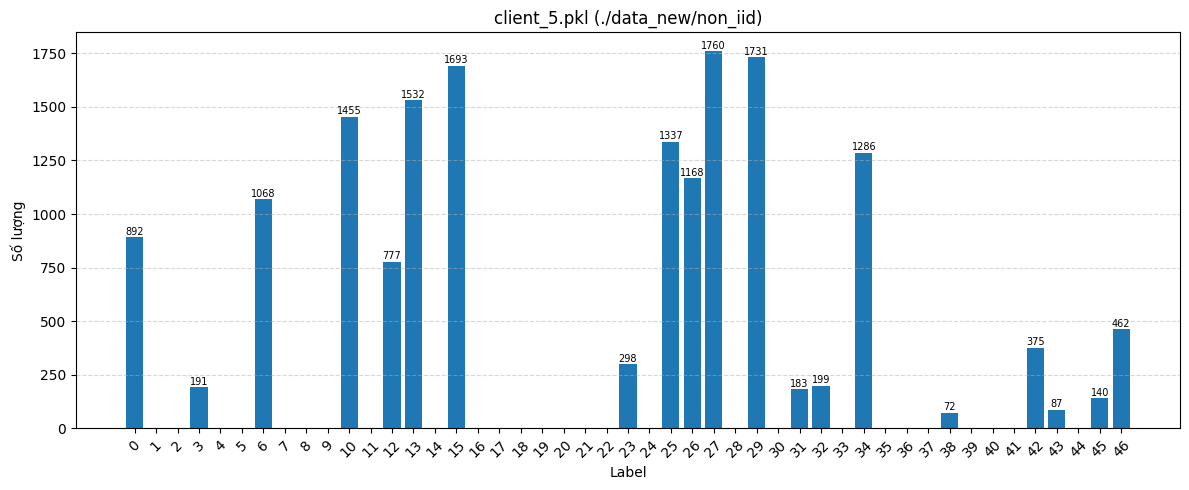

In [19]:
import os
import pickle
from collections import Counter
import matplotlib.pyplot as plt

def plot_each_client_beautiful(folder_path):
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".pkl")])

    for file in files:
        with open(os.path.join(folder_path, file), "rb") as f:
            data = pickle.load(f)

        y = data["labels"]
        counter = Counter(y)

        all_labels = list(range(max(counter.keys()) + 1))
        values = [counter.get(l, 0) for l in all_labels]

        plt.figure(figsize=(12,5))
        bars = plt.bar(all_labels, values)

        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.text(bar.get_x() + bar.get_width()/2,
                         height + 2,
                         str(int(height)),
                         ha='center', va='bottom', fontsize=7)

        plt.xticks(all_labels, rotation=45) 

        plt.xlabel("Label")
        plt.ylabel("Số lượng")
        plt.title(f"{file} ({folder_path})")

        plt.grid(axis='y', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()


# chạy
plot_each_client_beautiful("./data_new/non_iid")

In [20]:
import os
import pickle
from collections import defaultdict

data_dir = "data_new/non_iid"  # đổi path nếu cần

client_labels = {}
label_clients = defaultdict(list)

# ===============================
# 1. Đọc dữ liệu từng client
# ===============================
for file in os.listdir(data_dir):
    if file.endswith(".pkl"):
        client_id = file.replace("client_", "").replace(".pkl", "")

        with open(os.path.join(data_dir, file), "rb") as f:
            data = pickle.load(f)

        labels = set(data["labels"])  # unique labels

        client_labels[client_id] = labels

# ===============================
# 2. In labels của từng client
# ===============================
print("===== CLIENT -> LABELS =====")
for client, labels in client_labels.items():
    print(f"client_{client}: {sorted(labels)} (total {len(labels)})")

# ===============================
# 3. Đảo ngược: LABEL -> CLIENTS
# ===============================
for client, labels in client_labels.items():
    for l in labels:
        label_clients[l].append(client)

print("\n===== LABEL -> CLIENTS =====")
for l in sorted(label_clients.keys()):
    print(f"label {l}: clients {label_clients[l]}")

===== CLIENT -> LABELS =====
client_0: [1, 4, 9, 10, 11, 16, 19, 21, 25, 26, 28, 35, 36, 37, 42, 43] (total 16)
client_1: [0, 3, 8, 13, 14, 16, 17, 20, 22, 32, 34, 35, 36, 40] (total 14)
client_2: [1, 2, 5, 7, 8, 9, 11, 12, 14, 16, 18, 20, 31, 33, 37, 39, 40, 41, 44, 45, 46] (total 21)
client_3: [0, 3, 6, 7, 8, 9, 15, 17, 18, 19, 20, 21, 22, 23, 24, 28, 29, 30, 33, 34, 38, 39, 45] (total 23)
client_4: [1, 2, 4, 5, 7, 17, 21, 23, 24, 25, 27, 30, 31, 32, 38, 41, 43, 44, 46] (total 19)
client_5: [0, 3, 6, 10, 12, 13, 15, 23, 25, 26, 27, 29, 31, 32, 34, 38, 42, 43, 45, 46] (total 20)

===== LABEL -> CLIENTS =====
label 0: clients ['1', '3', '5']
label 1: clients ['0', '2', '4']
label 2: clients ['2', '4']
label 3: clients ['1', '3', '5']
label 4: clients ['0', '4']
label 5: clients ['2', '4']
label 6: clients ['3', '5']
label 7: clients ['2', '3', '4']
label 8: clients ['1', '2', '3']
label 9: clients ['0', '2', '3']
label 10: clients ['0', '5']
label 11: clients ['0', '2']
label 12: clien